# Flight Delay Prediction: Baseline Model

Working notebook for the [Zindi Flight Delay Prediction Challenge](https://zindi.africa/competitions/flight-delay-prediction-challenge) (Tunisair). This notebook builds Milestone 1: the **baseline model**, following the plan in `Flight_Delay_Baseline_and_Strategy_Report.pdf`.

## Define the Business Goal

- **Stakeholder:** Tunisair operations / the Zindi organisers evaluating submissions.
- **Prediction:** the delay of a given Tunisair flight, **in minutes** (can be negative for an early departure/arrival).
- **Problem type:** regression -- the target is a continuous number, not a delayed/not-delayed label.
- **Evaluation metric: Root Mean Squared Error (RMSE).** RMSE squares each error before averaging, so a few very large misses hurt the score far more than many small ones. This favours models that avoid big outlier misses over models that are only accurate on average, and it is also the metric the Zindi leaderboard scores submissions on.
- **Baseline model:** the simplest rule that makes a prediction. Two are built below -- a **naive mean/median predictor** (the absolute floor) and a **Ridge regression** on basic engineered features (the first "real" ML baseline). Every later, more complex model (Random Forest, LightGBM, CatBoost, ...) must beat these to justify its added complexity.

## Get the Data

> [!IMPORTANT]
> This repo does not ship the competition data in full. `data/Train.csv` is checked in; download `Test.csv` and `SampleSubmission.csv` from the **Data** tab of the [challenge page](https://zindi.africa/competitions/flight-delay-prediction-challenge) (Zindi account required) and place them in `data/` too once you're ready to produce a leaderboard submission. This notebook's baselines only need `Train.csv` -- they validate on a held-out, time-based slice of the training data itself.

Expected schema (per the strategy report -- verify against `train.info()` below, column names may differ slightly):

| Column | Meaning |
|---|---|
| `ID` | unique row identifier |
| `DATOP` | date of operation of the flight |
| `FLTID` | flight number (high-cardinality categorical) |
| `DEPSTN` | departure station / airport code |
| `ARRSTN` | arrival station / airport code |
| `STD` | scheduled time of departure |
| `STA` | scheduled time of arrival |
| `STATUS` | flight status code |
| `AC` | aircraft registration/type |
| `target` | delay in minutes (train only) -- what we predict for test |

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("data/Train.csv")

# Test.csv isn't checked into the repo yet (only needed for a leaderboard submission,
# not for building/validating the baselines below) -- load it if present, otherwise
# carry on with train-only.
try:
    test = pd.read_csv("data/Test.csv")
except FileNotFoundError:
    test = None
    print("data/Test.csv not found -- continuing with train-only baselines.")

# Parse the date columns explicitly with errors="coerce" rather than via read_csv's
# parse_dates. A handful of malformed/mixed-format values otherwise leave the whole
# column as object dtype (a mix of Timestamps and raw strings), which later raises
# "TypeError: cannot subtract DatetimeArray from ndarray[object]" when we compute the
# scheduled block time. Coercing unparseable values to NaT keeps every column a proper
# datetime64 dtype throughout.
#
# STA is also a known data quirk in this dataset: it uses dots as the time separator
# ("2016-01-03 12.55.00") instead of colons like STD and DATOP ("2016-01-03 10:30:00"),
# which pandas can't parse at all -- left as-is, every single STA value comes out NaT.
# Normalise dots to colons first so it parses like the other two.
for df in (train, test):
    if df is None:
        continue
    df["STA"] = df["STA"].str.replace(".", ":", regex=False)
    for col in ["DATOP", "STD", "STA"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")

train.head()

data/Test.csv not found -- continuing with train-only baselines.


,ID,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0


### First Look at the Data

A quick structural check: column types, missingness, and the target distribution.

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 107833 entries, 0 to 107832
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ID      107833 non-null  str           
 1   DATOP   107833 non-null  datetime64[us]
 2   FLTID   107833 non-null  str           
 3   DEPSTN  107833 non-null  str           
 4   ARRSTN  107833 non-null  str           
 5   STD     107833 non-null  datetime64[us]
 6   STA     107833 non-null  datetime64[us]
 7   STATUS  107833 non-null  str           
 8   AC      107833 non-null  str           
 9   target  107833 non-null  float64       
dtypes: datetime64[us](3), float64(1), str(6)
memory usage: 8.2 MB


In [3]:
# The target is right-skewed with a long tail of large delays (and can be negative
# for early flights) -- this shapes both the baseline choice and the evaluation metric's
# behaviour (RMSE punishes the tail hardest).
train["target"].describe()

count    107833.000000
mean         48.733013
std         117.135562
min           0.000000
25%           0.000000
50%          14.000000
75%          43.000000
max        3451.000000
Name: target, dtype: float64

## Train / Validation Split

We use a **time-based split**, not a random train/test split: earlier dates for training, the most recent ~20% of dates held out for validation. This matters for two reasons:

1. Several natural features for this problem (historical average delay per route/aircraft/flight number, delay-propagation from the same aircraft's earlier flight that day) are computed **over time**. A random split would let information from "future" rows leak into a "past" row's historical average, and a random shuffled CV on time-ordered data overstates validation performance.
2. It mirrors how the model will actually be used: predicting delays for flights that have not happened yet, from patterns learned on flights that already have.

A larger iteration of this project would use forward-chaining CV (several expanding time windows) instead of a single cut -- see the strategy report, Section 8.

In [4]:
train = train.sort_values("DATOP")

# Hold out the most recent ~20% of dates for validation
cutoff = train["DATOP"].quantile(0.8)
X_train, X_val = train[train["DATOP"] <= cutoff], train[train["DATOP"] > cutoff]

print(f"Train: {len(X_train)} rows up to {X_train['DATOP'].max().date()}")
print(f"Validation: {len(X_val)} rows from {X_val['DATOP'].min().date()} onward")

Train: 86352 rows up to 2018-06-01
Validation: 21481 rows from 2018-06-02 onward


## Baseline Models

Before training a real model, we set the RMSE floor with three baselines of increasing sophistication. Each is fit on `X_train` only and scored on `X_val` with RMSE.

In [5]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

### Baseline 0 -- Constant Predictor

Ignore every feature; always predict the training set's mean delay. If a later model cannot beat this, it has learned nothing useful.

In [6]:
baseline0_pred = np.full(len(X_val), X_train["target"].mean())
rmse_baseline0 = rmse(X_val["target"], baseline0_pred)

print(f"Baseline 0 (constant mean) always predicts: {X_train['target'].mean():.2f} minutes")
print(f"Baseline 0 validation RMSE: {rmse_baseline0:.2f}")

Baseline 0 (constant mean) always predicts: 44.90 minutes
Baseline 0 validation RMSE: 142.10


### Baseline 1 -- Group-Mean Predictor

Predict the historical mean delay of the flight's **route** (`DEPSTN`-`ARRSTN`), computed on training data only. No modelling required, but it already captures "this route is chronically late" signal.

In [7]:
route_mean = (
    X_train.assign(route=X_train["DEPSTN"].astype(str) + "_" + X_train["ARRSTN"].astype(str))
    .groupby("route")["target"].mean()
)
global_mean = X_train["target"].mean()  # fallback for routes not seen in training

val_route = X_val["DEPSTN"].astype(str) + "_" + X_val["ARRSTN"].astype(str)
baseline1_pred = val_route.map(route_mean).fillna(global_mean)
rmse_baseline1 = rmse(X_val["target"], baseline1_pred)

print(f"Baseline 1 (route mean) validation RMSE: {rmse_baseline1:.2f}")

Baseline 1 (route mean) validation RMSE: 139.60


### Baseline 2 -- Ridge Regression

A simple linear model over basic engineered features: hour of day, day of week, month, scheduled block time, and route. This is the first baseline that is a real (if simple) ML model, and the reference point for whether tree ensembles (Random Forest, LightGBM, CatBoost -- the next iteration) are actually earning their extra complexity.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def add_features(df):
    df = df.copy()
    df["hour"] = df["STD"].dt.hour
    df["dow"] = df["STD"].dt.dayofweek
    df["month"] = df["STD"].dt.month
    df["block_min"] = (df["STA"] - df["STD"]).dt.total_seconds() / 60
    df["block_min"] = df["block_min"].fillna(df["block_min"].median())
    df["route"] = df["DEPSTN"].astype(str) + "_" + df["ARRSTN"].astype(str)
    return df

X_train_feat = add_features(X_train)
X_val_feat = add_features(X_val)

cat_cols = ["route", "DEPSTN", "ARRSTN"]
num_cols = ["hour", "dow", "month", "block_min"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

baseline2 = Pipeline([("preprocess", preprocess), ("reg", Ridge(alpha=1.0))])
baseline2.fit(X_train_feat[cat_cols + num_cols], X_train_feat["target"])

baseline2_pred = baseline2.predict(X_val_feat[cat_cols + num_cols])
rmse_baseline2 = rmse(X_val["target"], baseline2_pred)

print(f"Baseline 2 (Ridge regression) validation RMSE: {rmse_baseline2:.2f}")

Baseline 2 (Ridge regression) validation RMSE: 138.74


## Tree Ensembles: Random Forest and XGBoost

The baselines above set the RMSE floor. We now try two tree-ensemble models on the **same engineered features** (`X_train_feat` / `X_val_feat` from Baseline 2) to see whether they earn their added complexity over a linear model.

Both are trained with one-hot encoded categoricals for a fair, apples-to-apples comparison with Ridge -- native categorical handling (CatBoost/LightGBM) is future work per the strategy report.

### Random Forest

An ensemble of de-correlated decision trees, each trained on a bootstrap sample with a random subset of features at each split, averaged together. Unlike Ridge, it can capture non-linear effects and interactions (e.g. "delays are worse on weekend evenings at this specific route") without us having to engineer them by hand.

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocess", preprocess),
    ("reg", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    )),
])
rf_model.fit(X_train_feat[cat_cols + num_cols], X_train_feat["target"])

rf_pred = rf_model.predict(X_val_feat[cat_cols + num_cols])
rmse_rf = rmse(X_val["target"], rf_pred)

print(f"Random Forest validation RMSE: {rmse_rf:.2f}")

Random Forest validation RMSE: 139.07


#### Random Forest Feature Importance

Which features the forest actually splits on -- a sanity check that it is learning something plausible, and a pointer to which engineered features are worth refining next.

In [10]:
rf_feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
rf_importances = pd.Series(
    rf_model.named_steps["reg"].feature_importances_, index=rf_feature_names
).sort_values(ascending=False)

rf_importances.head(15)

remainder__month        0.222018
remainder__hour         0.196673
remainder__block_min    0.139561
remainder__dow          0.089380
cat__route_TUN_TUN      0.087124
cat__route_SXF_TUN      0.018370
cat__route_HAM_DJE      0.013056
cat__route_MIR_CDG      0.011980
cat__DEPSTN_CZL         0.010898
cat__route_ALG_TUN      0.009148
cat__route_DJE_DJE      0.008393
cat__DEPSTN_TUN         0.007110
cat__route_TUN_ALG      0.006416
cat__route_CDG_TUN      0.005582
cat__DEPSTN_IST         0.004974
dtype: float64

### XGBoost

A gradient-boosted tree ensemble: trees are added sequentially, each one fit to correct the residual errors of the ensemble so far, rather than averaged independently like Random Forest. It is the closest of the two to the CatBoost/LightGBM models recommended as the next iteration in the strategy report, and often the strongest tabular model for this kind of skewed, tail-heavy target.

In [11]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocess", preprocess),
    ("reg", XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )),
])
xgb_model.fit(X_train_feat[cat_cols + num_cols], X_train_feat["target"])

xgb_pred = xgb_model.predict(X_val_feat[cat_cols + num_cols])
rmse_xgb = rmse(X_val["target"], xgb_pred)

print(f"XGBoost validation RMSE: {rmse_xgb:.2f}")

XGBoost validation RMSE: 138.15


#### XGBoost Feature Importance

In [12]:
xgb_feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
xgb_importances = pd.Series(
    xgb_model.named_steps["reg"].feature_importances_, index=xgb_feature_names
).sort_values(ascending=False)

xgb_importances.head(15)

cat__route_TUN_TUN    0.037559
cat__route_DJE_TUN    0.020438
cat__route_TUN_ORY    0.019608
cat__route_MRS_TUN    0.013333
cat__route_TUN_SVO    0.013315
cat__ARRSTN_ORY       0.011522
cat__route_ALG_TUN    0.010986
cat__route_TUN_SXF    0.010787
cat__DEPSTN_SFA       0.009109
cat__route_DJE_DJE    0.008788
cat__route_TUN_IST    0.008773
cat__route_TUN_ALG    0.008716
cat__DEPSTN_DJE       0.008395
cat__route_MIR_MRS    0.008289
cat__DEPSTN_ALG       0.008170
dtype: float32

### Compare All Models

In [13]:
results = pd.DataFrame({
    "model": ["Constant mean", "Route mean", "Ridge regression", "Random Forest", "XGBoost"],
    "validation_rmse": [rmse_baseline0, rmse_baseline1, rmse_baseline2, rmse_rf, rmse_xgb],
}).sort_values("validation_rmse").reset_index(drop=True)

results

,model,validation_rmse
0,XGBoost,138.145406
1,Ridge regression,138.739841
2,Random Forest,139.073117
3,Route mean,139.597900
4,Constant mean,142.102752


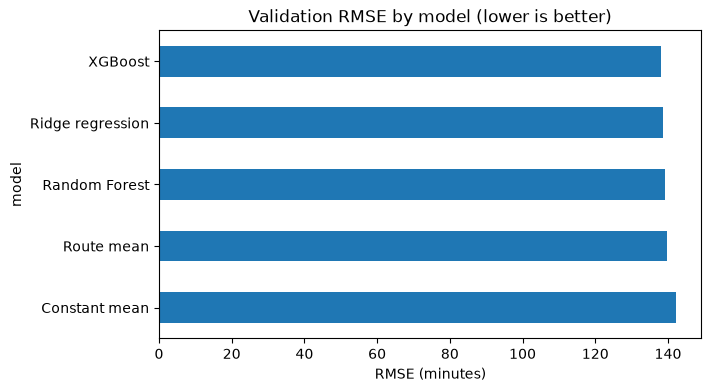

In [14]:
ax = results.set_index("model")["validation_rmse"].plot(
    kind="barh", figsize=(7, 4), title="Validation RMSE by model (lower is better)"
)
ax.set_xlabel("RMSE (minutes)")
ax.invert_yaxis()

Whichever model scores lowest here is the number the next iteration (richer features, native-categorical CatBoost/LightGBM, tuning) has to beat. Random Forest and XGBoost are trained here with reasonable defaults, not yet tuned -- the gap between them and Ridge is the more informative signal at this stage than either's absolute score.

## Next Steps

Per the strategy report's roadmap (Sections 3, 6-7):

1. Expand feature engineering: cyclical hour/month encoding, part-of-day buckets, an airport-traffic proxy, and -- carefully, using only past rows -- expanding-mean delay per aircraft/route/flight number and same-day delay-propagation.
2. Move to gradient-boosted trees with native categorical handling (CatBoost first, for `FLTID`/`DEPSTN`/`ARRSTN`/`AC`; LightGBM alongside it for fast iteration), tuned with forward-chaining time-based CV, early stopping, and a hyperparameter search (the Random Forest and XGBoost above use untuned defaults).
3. Try `log1p(target)` or a Huber loss to reduce the influence of extreme delays, comparing against raw-minute training on the same validation split.
4. Blend/stack the strongest 2-3 models for the final submission.
5. Do error analysis by route, month, and delay magnitude before the final retrain-on-everything and `submission.csv` write-out (columns `id`, `target`, matching `SampleSubmission.csv` exactly).

## References & Further Reading

- [**Flight Delay Prediction Challenge (Zindi)**](https://zindi.africa/competitions/flight-delay-prediction-challenge): the competition this notebook targets.
- `Flight_Delay_Baseline_and_Strategy_Report.pdf`: the fuller strategy report this notebook implements (data caveats, feature ideas, model comparison, validation pitfalls).
- [**root_mean_squared_error (scikit-learn)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html): the evaluation metric used here and by the leaderboard.
- [**Ridge (scikit-learn)**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html): the model behind Baseline 2.
- [**RandomForestRegressor (scikit-learn)**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html): the Random Forest model above.
- [**XGBoost Python API (XGBRegressor)**](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor): the XGBoost model above.
- [**Common pitfalls and recommended practices (scikit-learn)**](https://scikit-learn.org/stable/common_pitfalls.html): general guidance on data leakage, directly relevant to the historical-average features planned for the next iteration.